In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
conditioning_list = [4 ** i for i in range(5)]
n_runs = 3

mcmc_array     = np.empty((n_runs, 5))
mcmc_std_array = np.empty((n_runs, 5))
for i in range(n_runs):
    input_dir = f"budget_results{i}"
    mcmc_array[i, :]     = np.load(os.path.join(input_dir, "swd_mcmc_array_mean.npy"))
    mcmc_std_array[i, :] = np.load(os.path.join(input_dir, "swd_mcmc_array_std.npy"))

# Load nn arrays from whichever runs have them
nn_run_means = []
for i in range(n_runs):
    nn_path = os.path.join(f"budget_results{i}", f"swd_nn_array_{i}.npy")
    if os.path.exists(nn_path):
        nn_run_means.append(np.mean(np.load(nn_path), axis=0))
nn_runs = np.array(nn_run_means)

wd_mcmc_means = np.mean(mcmc_array, axis=0)
wd_mcmc_std   = np.mean(mcmc_std_array, axis=0)
nn_mean = float(np.mean(nn_runs))   # scalar: mean SWD across all chains and runs
nn_std  = float(np.std(nn_runs)) if len(nn_run_means) > 1 else 0.0

# print(f"Loaded nn arrays from {len(nn_run_means)} run(s): mean={nn_mean:.4f}, std={nn_std:.4f}")
# print(f"MCMC means: {wd_mcmc_means}")

In [3]:
nn_runs

array([0.05227458, 0.05232277])

In [4]:
wd_mcmc_means

array([0.01381163, 0.036555  , 0.04527799, 0.0908923 , 0.09121384])

In [5]:
mcmc_array

array([[0.01354009, 0.02735489, 0.04440617, 0.09193134, 0.09142747],
       [0.01477052, 0.04211093, 0.04568634, 0.08873916, 0.09082653],
       [0.01312429, 0.04019919, 0.04574145, 0.0920064 , 0.09138752]])

In [6]:
# Find which budget interval nn_mean falls in and interpolate the crossing x-value
# Search between adjacent MCMC curve points
vline_idx = None
for seg_lo, seg_hi in zip(range(len(conditioning_list) - 1), range(1, len(conditioning_list))):
    lo, hi = wd_mcmc_means[seg_lo], wd_mcmc_means[seg_hi]
    if min(lo, hi) <= nn_mean <= max(lo, hi):
        a = np.linspace(lo, hi, 500)
        b = np.linspace(conditioning_list[seg_lo], conditioning_list[seg_hi], 500)
        vline_idx = float(np.interp(nn_mean, a, b))
        break
print(f"Crossing x ≈ {vline_idx}")

Crossing x ≈ 23.38788048393378


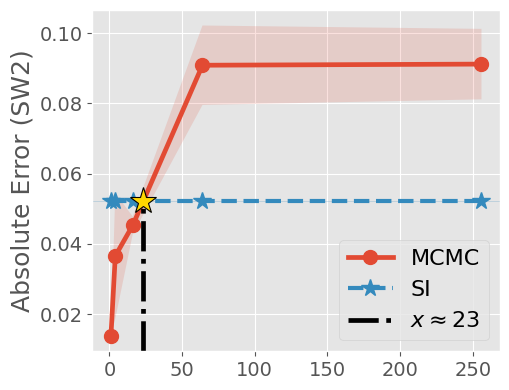

In [13]:
fig, ax = plt.subplots(figsize=(5.2, 4))

ax.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o", linewidth=3.4, markersize=10)
ax.fill_between(
    conditioning_list,
    wd_mcmc_means - wd_mcmc_std,
    wd_mcmc_means + wd_mcmc_std,
    alpha=0.16,
)

# ax.axhline(nn_mean, label="SI - ODE", linestyle="dashed", linewidth=3, color="C1")
ax.plot(conditioning_list, np.ones(len(conditioning_list)) * nn_mean, label="SI", linestyle="dashed", color="C1", linewidth=3, marker="*", markersize=13)
if nn_std > 0:
    ax.axhspan(nn_mean - nn_std, nn_mean + nn_std, alpha=0.3, color="C1")

if vline_idx is not None:
    ymin_data, ymax_data = ax.get_ylim()
    ymax_norm = (nn_mean - ymin_data) / (ymax_data - ymin_data)
    ax.axvline(vline_idx, ymax=ymax_norm, linewidth=3.4, label=rf"$x \approx${vline_idx:.0f}", c="black", linestyle="dashdot")

ax.plot(vline_idx, nn_mean, linestyle="None", marker="*", 
        c="gold", markeredgecolor="black", markeredgewidth=0.8, markersize=20)
ax.annotate(rf"$n \approx {vline_idx:.0f}$", 
            xy=(vline_idx, 0),          # point to the x-axis intercept
            xytext=(vline_idx + 10, 0.01),
            fontsize=9, va="bottom",
            arrowprops=dict(arrowstyle="-", color="black", lw=0.8))
ax.tick_params(axis="both", labelsize=14)
ax.legend(fontsize=16)
# ax.set_xlabel("# Posteriors")
ax.set_ylabel("Absolute Error (SW2)", fontsize=18)
os.makedirs("../images", exist_ok=True)
plt.tight_layout()
fig.savefig("../images/budget_p_poisson.png", dpi=300, bbox_inches="tight")
plt.show()

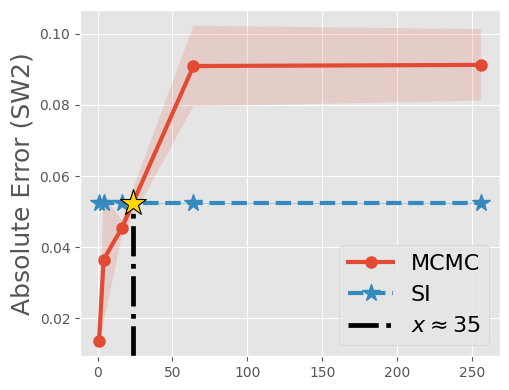

In [12]:
fig, ax = plt.subplots(figsize=(5.2, 4))

ax.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o", linewidth=3, markersize=8)
ax.fill_between(conditioning_list, wd_mcmc_means - wd_mcmc_std, wd_mcmc_means + wd_mcmc_std, alpha=0.16)
ax.plot(conditioning_list, nn_mean * np.ones(len(conditioning_list)), label="SI", linestyle="dashed", linewidth=3, marker="*", markersize=13)
ax.fill_between(conditioning_list, (nn_mean - nn_std) * np.ones(len(conditioning_list)), (nn_mean + nn_std) * np.ones(len(conditioning_list)), alpha=0.3)
ymin_data, ymax_data = ax.get_ylim()
ymax_norm = (nn_mean - ymin_data) / (ymax_data - ymin_data)
ax.axvline(vline_idx, ymax=ymax_norm, linewidth=3.4, label=rf"$x \approx${35}", c="black", linestyle="dashdot")
ax.plot(vline_idx, nn_mean, linestyle="None", marker="*", 
        c="gold", markeredgecolor="black", markeredgewidth=0.8, markersize=20)
ax.annotate(rf"$n \approx {vline_idx:.0f}$", 
            xy=(vline_idx, 0),          # point to the x-axis intercept
            xytext=(vline_idx + 10, 0.01),
            fontsize=9, va="bottom",
            arrowprops=dict(arrowstyle="-", color="black", lw=0.8))
ax.legend(fontsize=16)
# ax.set_tick_params(axis="both", labelsize=15.4)
# plt.yscale("log")
# plt.xscale("log")
# plt.xlabel("# Posteriors")
ax.set_ylabel("Absolute Error (SW2)", fontsize=18)
plt.tight_layout()
plt.savefig("../images/budget_p_poisson.png", dpi=300, bbox_inches="tight")